In [2]:
# https://chatgpt.com/share/6a9da961-165c-83e8-aef5-9ac962a1e116

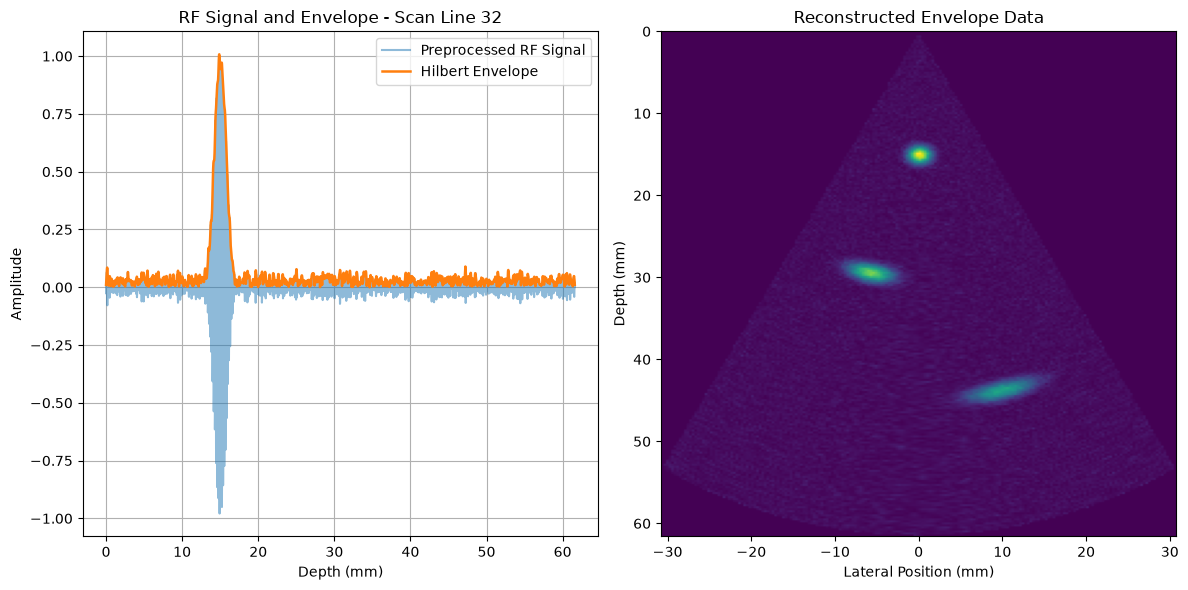

Reconstructed envelope shape: (250, 200)
Depth range: 0.0 to 61.599999999999994 mm
Lateral range: -30.799999999999994 to 30.799999999999994 mm


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
from scipy.interpolate import griddata

# ==========================================
# STEP 1: Beamformed RF Data Input
# ==========================================
# We receive beamformed RF data from the beamforming team.
# Here, we simulate a 5 MHz center-frequency transducer
# with 64 ultrasound scan lines.

fs = 40e6         # Sampling frequency = 40 MHz
fc = 5e6          # Transducer center frequency = 5 MHz
c = 1540          # Speed of sound in tissue = 1540 m/s
num_lines = 64    # Number of scan lines
t_max = 80e-6     # Maximum acquisition time = 80 microseconds


# Time samples
t = np.arange(0, t_max, 1 / fs)
num_samples = len(t)

# RF data matrix: Samples × Scanlines
np.random.seed(42)
rf_matrix = np.zeros((num_samples, num_lines))


# ==========================================
# Define Simulated Point Targets
# ==========================================
# Format:
# (depth in meters, scan-line index, reflectivity)

targets = [
    (0.015, 32, 1.0),   # Target at 15 mm
    (0.030, 20, 0.8),   # Target at 30 mm
    (0.045, 45, 0.6)    # Target at 45 mm
]

# ==========================================
# Generate Simulated RF Echoes
# ==========================================

for depth, line_idx, strength in targets:

    # Round-trip echo arrival time
    t_echo = (2 * depth) / c

    # Pulse duration
    pulse_width = 1.0e-6

    for l in range(num_lines):

        # Distance from target's main scan line
        lateral_distance = abs(l - line_idx)

        # Simulate lateral spreading of the echo
        lateral_attenuation = np.exp(
            -(lateral_distance ** 2) / (2 * 4.0 ** 2)
        )

        if lateral_attenuation > 0.01:

            # Gaussian-modulated RF carrier
            pulse = (
                strength
                * lateral_attenuation
                * np.exp(
                    -((t - t_echo) ** 2)
                    / (2 * pulse_width ** 2)
                )
                * np.cos(
                    2 * np.pi * fc * (t - t_echo)
                )
            )

            rf_matrix[:, l] += pulse

# ==========================================
# Add DC Bias and Random Noise
# ==========================================

dc_bias = 0.08

noise = np.random.normal(
    0,
    0.05,
    rf_matrix.shape
)

raw_rf_input = rf_matrix + dc_bias + noise

# ==========================================
# STEP 2: RF Data Preprocessing
# ==========================================

# ------------------------------------------
# 2.1 DC Offset Removal
# ------------------------------------------

rf_no_dc = (
    raw_rf_input
    - np.mean(raw_rf_input, axis=0)
)

# ------------------------------------------
# 2.2 Bandpass Filtering
# ------------------------------------------

low_cut = 2.0e6
high_cut = 8.0e6

nyquist = 0.5 * fs

b, a = butter(
    2,
    [
        low_cut / nyquist,
        high_cut / nyquist
    ],
    btype='bandpass'
)

# Zero-phase filtering
preprocessed_rf = filtfilt(
    b,
    a,
    rf_no_dc,
    axis=0
)

# ==========================================
# STEP 3: Envelope Detection
# ==========================================
# Use Hilbert Transform to obtain the
# amplitude envelope of each RF scan line.

analytic_signal = hilbert(
    preprocessed_rf,
    axis=0
)

# Envelope = magnitude of analytic signal
envelope = np.abs(analytic_signal)

# ==========================================
# STEP 4: Time-to-Depth Conversion
# ==========================================
# z = c*t/2
#
# Factor of 2 is because ultrasound travels
# from the transducer to the target and back.

depth_mm = (
    (c * t) / 2
) * 1000


# ==========================================
# STEP 5: Spatial Reconstruction
# ==========================================
# Organize the envelope data according to
# lateral scan-line positions.

lateral_pitch_mm = 0.5

lateral_positions_mm = (
    np.arange(num_lines)
    * lateral_pitch_mm
)

# Reconstructed envelope in X-Z coordinates
E_xz = envelope

# ==========================================
# STEP 6: Scan Conversion
# ==========================================
# Convert the scan-line representation into
# a regular Cartesian spatial grid.

theta = np.linspace(
    -30,
    30,
    num_lines
) * np.pi / 180

theta_grid, r_grid = np.meshgrid(
    theta,
    depth_mm
)

# Polar → Cartesian coordinates

x_polar = (
    r_grid
    * np.sin(theta_grid)
)

z_polar = (
    r_grid
    * np.cos(theta_grid)
)


# ------------------------------------------
# Define Cartesian Grid
# ------------------------------------------

x_cart = np.linspace(
    np.min(x_polar),
    np.max(x_polar),
    200
)

z_cart = np.linspace(
    0,
    np.max(z_polar),
    250
)

X_grid, Z_grid = np.meshgrid(
    x_cart,
    z_cart
)

# ------------------------------------------
# Interpolation
# ------------------------------------------

points = np.vstack(
    (
        x_polar.flatten(),
        z_polar.flatten()
    )
).T

values = E_xz.flatten()

# Final reconstructed envelope
reconstructed_envelope = griddata(
    points,
    values,
    (X_grid, Z_grid),
    method='linear',
    fill_value=0.0
)

# ==========================================
# VISUALIZATION
# ==========================================

fig, axs = plt.subplots(
    1,
    2,
    figsize=(12, 6)
)


# ------------------------------------------
# Plot 1: RF Signal + Envelope
# ------------------------------------------

axs[0].plot(
    depth_mm,
    preprocessed_rf[:, 32],
    label="Preprocessed RF Signal",
    alpha=0.5
)

axs[0].plot(
    depth_mm,
    envelope[:, 32],
    label="Hilbert Envelope",
    linewidth=1.8
)

axs[0].set_title(
    "RF Signal and Envelope - Scan Line 32"
)

axs[0].set_xlabel(
    "Depth (mm)"
)

axs[0].set_ylabel(
    "Amplitude"
)

axs[0].grid(True)
axs[0].legend()

# ------------------------------------------
# Plot 2: Reconstructed Envelope
# ------------------------------------------

axs[1].imshow(
    reconstructed_envelope,
    extent=[
        x_cart[0],
        x_cart[-1],
        z_cart[-1],
        z_cart[0]
    ],
    aspect='auto'
)

axs[1].set_title(
    "Reconstructed Envelope Data"
)

axs[1].set_xlabel(
    "Lateral Position (mm)"
)

axs[1].set_ylabel(
    "Depth (mm)"
)


plt.tight_layout()
plt.show()


# ==========================================
# FINAL OUTPUT
# ==========================================

print(
    "Reconstructed envelope shape:",
    reconstructed_envelope.shape
)

print(
    "Depth range:",
    depth_mm[0],
    "to",
    depth_mm[-1],
    "mm"
)

print(
    "Lateral range:",
    x_cart[0],
    "to",
    x_cart[-1],
    "mm"
)


